# Part 1 — ETL + ML Model
## 1.1 ETL Pipeline
Extracts raw SimFin data, computes technical features, adds the target variable, and saves one processed CSV per ticker to `../data/processed/`.

---

In [3]:
import os
import numpy as np
import pandas as pd

# Edit INPUT_PATH to point to your SimFin bulk download files
INPUT_PATH     = "../data/raw/us-shareprices-daily.csv"
COMPANIES_PATH = "../data/raw/us-companies.csv"
OUTPUT_DIR     = "../data/processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load raw share prices

In [4]:
df_share_prices = pd.read_csv(INPUT_PATH, delimiter=";")
print("Shape:", df_share_prices.shape)
df_share_prices.head()

Shape: (6205521, 11)


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
0,A,45846,2020-04-07,76.61,77.56,74.02,74.03,71.17,2458009,NaN,309651359.0
1,A,45846,2020-04-08,74.17,77.17,72.75,76.69,73.73,2702954,NaN,309651359.0
2,A,45846,2020-04-09,76.43,78.72,76.23,78.33,75.31,2399863,NaN,309651359.0
3,A,45846,2020-04-13,77.44,77.99,75.02,76.21,73.27,1533000,NaN,309651359.0
4,A,45846,2020-04-14,77.30,79.20,77.24,78.83,75.79,2650262,NaN,309651359.0


## Load companies list

In [5]:
df_companies = pd.read_csv(COMPANIES_PATH, delimiter=";")
print("Shape:", df_companies.shape)
df_companies.sort_values("Number Employees", ascending=False).head(10)

Shape: (6531, 11)


,Ticker,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency
399,AMZN,62747,AMAZON COM INC,103002.0,US0231351067,12.0,1298000.0,Amazon.com Inc is an online retailer. The Comp...,us,1018724.0,USD
6008,UPS,106423,UNITED PARCEL SERVICE INC,100010.0,US9113121068,12.0,543000.0,United Parcel Service Inc is a package deliver...,us,1090727.0,USD
120,ACN,61372,Accenture plc,108002.0,IE00B4BNMY34,8.0,506000.0,Accenture PLC is a professional service compan...,us,1467373.0,USD
2827,HOME,233408,At Home Group Inc.,103002.0,US04650Y1001,1.0,400000.0,At Home Group Inc is a home décor superstore. ...,us,1646228.0,USD
5692,TESS,42813,TESSCO TECHNOLOGIES INC,101005.0,US8723861071,3.0,391500.0,Tessco Technologies Inc architects and deliver...,us,927355.0,USD
961,BRK-A,71306,BERKSHIRE HATHAWAY INC,111001.0,US0846701086,12.0,371653.0,"Berkshire Hathaway Inc., through its subsidiar...",us,1067983.0,USD
2308,FMX,18773575,"Fomento Económico Mexicano, S.A.B. de C.V.",102004.0,US3444191064,12.0,350000.0,"Fomento Económico Mexicano, S.A.B. de C.V., th...",us,1061736.0,USD
5129,SBUX,86689,STARBUCKS CORP,103003.0,US8552441094,9.0,349000.0,"Starbucks Corp is the roaster, marketer and re...",us,829224.0,USD
2944,IBM,69543,INTERNATIONAL BUSINESS MACHINES CORP,101003.0,US4592001014,12.0,345900.0,International Business Machines Corp offers a ...,us,51143.0,USD
5794,TNET,797860,TRINET GROUP INC,100002.0,US8962881079,12.0,334600.0,Trinet Group Inc provides human resources solu...,us,937098.0,USD


## Step 1 — Filter to one company
Build and test on AMZN first. Once it works, run for all tickers at the end.

In [6]:
def filter_company(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Filter to one ticker and sort chronologically."""
    company_df = df[df["Ticker"] == ticker].copy()
    company_df.sort_values("Date", ascending=True, inplace=True)
    company_df.reset_index(drop=True, inplace=True)
    return company_df

df_amzn = filter_company(df_share_prices, "AMZN")
print(f"AMZN rows: {len(df_amzn)}")
df_amzn.head()

AMZN rows: 1238


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
0,AMZN,62747,2020-04-07,100.86,101.79,99.88,100.58,100.58,102279660,NaN,9.980000e+09
1,AMZN,62747,2020-04-08,101.05,102.20,100.56,102.15,102.15,79546260,NaN,9.980000e+09
2,AMZN,62747,2020-04-09,102.22,102.65,100.88,102.14,102.14,93112340,NaN,9.980000e+09
3,AMZN,62747,2020-04-13,102.00,109.00,101.90,108.44,108.44,134334180,NaN,9.980000e+09
4,AMZN,62747,2020-04-14,110.02,114.60,109.31,114.17,114.17,161743860,NaN,9.980000e+09


## Step 2 — Add technical features

In [7]:
def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute 8 technical indicator features from raw share price data.
    Drops rows with NaN values caused by rolling windows.
    """
    df = df.copy()

    # Daily log-return
    df["Returns"] = np.log(df["Close"] / df["Close"].shift(1))

    # Simple Moving Averages
    df["SMA_5"]  = df["Close"].rolling(window=5).mean()   # 1 trading week
    df["SMA_20"] = df["Close"].rolling(window=20).mean()  # ~1 trading month

    # Rolling volatility (std of returns)
    df["Volatility_5"]  = df["Returns"].rolling(window=5).std()
    df["Volatility_20"] = df["Returns"].rolling(window=20).std()

    # Volume change
    df["Volume_Change"] = df["Volume"].pct_change()

    # RSI (14-day)
    delta    = df["Close"].diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs       = avg_gain / avg_loss
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # Normalised price range
    df["Price_Range"] = (df["High"] - df["Low"]) / df["Close"]

    feature_cols = [
        "Returns", "SMA_5", "SMA_20",
        "Volatility_5", "Volatility_20",
        "Volume_Change", "RSI_14", "Price_Range"
    ]
    df = df.dropna(subset=feature_cols).reset_index(drop=True)
    return df

df_amzn = add_technical_features(df_amzn)
print(f"Shape after features: {df_amzn.shape}")
df_amzn[["Date","Close","Returns","SMA_5","RSI_14","Price_Range"]].head()

Shape after features: (1218, 19)


,Date,Close,Returns,SMA_5,RSI_14,Price_Range
0,2020-05-06,117.56,0.014307,117.450,45.977985,0.015907
1,2020-05-07,118.38,0.006951,116.386,49.465163,0.013854
2,2020-05-08,118.98,0.005056,117.322,48.978400,0.012691
3,2020-05-11,120.45,0.012279,118.252,56.223044,0.019676
4,2020-05-12,117.85,-0.021822,118.644,49.519520,0.027153


## Step 3 — Add target variable
`Target = 1` if tomorrow's Close > today's Close, else `0`.

In [8]:
def add_target(df: pd.DataFrame) -> pd.DataFrame:
    """Binary target: 1 = price rises tomorrow, 0 = falls. Last row gets NaN."""
    df = df.copy()
    df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(float)
    return df

df_amzn = add_target(df_amzn)
print("Target distribution:")
print(df_amzn["Target"].value_counts())
df_amzn[["Date","Close","Target"]].tail(5)

Target distribution:
Target
1.0    628
0.0    590
Name: count, dtype: int64


,Date,Close,Target
1213,2025-03-05,208.36,0.0
1214,2025-03-06,200.70,0.0
1215,2025-03-07,199.25,0.0
1216,2025-03-10,194.54,1.0
1217,2025-03-11,196.59,0.0


## Step 4 — Drop columns with many NaN values

In [9]:
def drop_columns_many_nans(df: pd.DataFrame, threshold: float = 0.75) -> pd.DataFrame:
    """Drop columns where the fraction of NaN exceeds threshold."""
    return df.loc[:, df.isna().mean() < threshold]

df_amzn = drop_columns_many_nans(df_amzn, threshold=0.75)
print("Remaining columns:", df_amzn.columns.tolist())
print("Any remaining NaN:", df_amzn.isnull().sum().sum())

Remaining columns: ['Ticker', 'SimFinId', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Shares Outstanding', 'Returns', 'SMA_5', 'SMA_20', 'Volatility_5', 'Volatility_20', 'Volume_Change', 'RSI_14', 'Price_Range', 'Target']
Any remaining NaN: 0


## Step 5 — Save processed file

In [10]:
def save_processed(df: pd.DataFrame, output_dir: str, ticker: str) -> str:
    """Save the processed DataFrame to CSV. Returns the file path."""
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, f"{ticker.lower()}_processed.csv")
    df.to_csv(path, index=False)
    print(f"[ETL] Saved {ticker}: {len(df)} rows -> {path}")
    return path

save_processed(df_amzn, OUTPUT_DIR, "AMZN")

[ETL] Saved AMZN: 1218 rows -> ../data/processed/amzn_processed.csv


'../data/processed/amzn_processed.csv'

## Step 6 — Full ETL pipeline function

In [11]:
def extract_share_prices(input_path: str) -> pd.DataFrame:
    """Load the raw SimFin share-prices CSV."""
    return pd.read_csv(input_path, delimiter=";")


def run_etl(input_path: str, output_dir: str, ticker: str) -> pd.DataFrame:
    """
    Execute the full ETL pipeline for a single ticker.
    Parameters: input_path, output_dir, ticker (e.g. AMZN)
    Returns the processed DataFrame (also saved to disk).
    """
    raw = extract_share_prices(input_path)
    df  = filter_company(raw, ticker)
    if df.empty:
        raise ValueError(f"No data found for ticker '{ticker}'.")
    df = add_technical_features(df)
    df = add_target(df)
    df = drop_columns_many_nans(df, threshold=0.75)
    save_processed(df, output_dir, ticker)
    return df

## Step 7 — Run ETL for all 5 tickers

In [12]:
TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]

for ticker in TICKERS:
    run_etl(INPUT_PATH, OUTPUT_DIR, ticker)

[ETL] Saved AMZN: 1218 rows -> ../data/processed/amzn_processed.csv
[ETL] Saved AAPL: 1218 rows -> ../data/processed/aapl_processed.csv
[ETL] Saved MSFT: 1218 rows -> ../data/processed/msft_processed.csv
[ETL] Saved GOOG: 1218 rows -> ../data/processed/goog_processed.csv
[ETL] Saved TSLA: 1218 rows -> ../data/processed/tsla_processed.csv


## Sanity check — inspect one processed file

In [13]:
df_check = pd.read_csv(f"{OUTPUT_DIR}/amzn_processed.csv")
print("Shape:", df_check.shape)
print("Columns:", df_check.columns.tolist())
print("\nTarget balance:")
print(df_check["Target"].value_counts())
df_check.tail(3)

Shape: (1218, 19)
Columns: ['Ticker', 'SimFinId', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Shares Outstanding', 'Returns', 'SMA_5', 'SMA_20', 'Volatility_5', 'Volatility_20', 'Volume_Change', 'RSI_14', 'Price_Range', 'Target']

Target balance:
Target
1.0    628
0.0    590
Name: count, dtype: int64


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Shares Outstanding,Returns,SMA_5,SMA_20,Volatility_5,Volatility_20,Volume_Change,RSI_14,Price_Range,Target
1215,AMZN,62747,2025-03-07,199.49,202.27,192.53,199.25,199.25,59802821,1.059773e+10,-0.007251,203.426,217.6890,0.024440,0.018462,0.199324,19.914128,0.048883,0.0
1216,AMZN,62747,2025-03-10,195.60,196.73,190.85,194.54,194.54,61829231,1.059773e+10,-0.023923,201.330,215.9585,0.022375,0.017225,0.033885,18.879628,0.030225,1.0
1217,AMZN,62747,2025-03-11,193.90,200.18,193.40,196.59,196.59,54002880,1.059773e+10,0.010483,199.888,214.1310,0.024331,0.016758,-0.126580,21.988064,0.034488,0.0


---
---
## 1.2 ML Model
Reads the processed CSVs from the ETL above, trains a Logistic Regression pipeline, evaluates it, and exports the model as a `.joblib` file for the Streamlit web app.

---

In [14]:
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection   import train_test_split, TimeSeriesSplit
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.metrics           import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROCESSED_DIR = "../data/processed"
MODELS_DIR    = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

FEATURE_COLS = [
    "Returns", "SMA_5", "SMA_20",
    "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range"
]
TARGET = "Target"

## Step 1 — Load ETL output
Do NOT re-run ETL here. Just read the CSV the ETL saved above.

In [15]:
TICKER = "AMZN"

df = pd.read_csv(f"{PROCESSED_DIR}/{TICKER.lower()}_processed.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df[TARGET].value_counts())
df.head()

Shape: (1218, 19)

Target distribution:
Target
1.0    628
0.0    590
Name: count, dtype: int64


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Shares Outstanding,Returns,SMA_5,SMA_20,Volatility_5,Volatility_20,Volume_Change,RSI_14,Price_Range,Target
0,AMZN,62747,2020-05-06,116.47,117.87,116.00,117.56,117.56,62356280,9.975521e+09,0.014307,117.450,115.8285,0.045687,0.031274,-0.038452,45.977985,0.015907,1.0
1,AMZN,62747,2020-05-07,118.74,118.80,117.16,118.38,118.38,67928220,9.975521e+09,0.006951,116.386,116.6400,0.039634,0.031221,0.089357,49.465163,0.013854,1.0
2,AMZN,62747,2020-05-08,118.61,119.36,117.85,118.98,118.98,64224560,9.975521e+09,0.005056,117.322,117.4820,0.005637,0.031178,-0.054523,48.978400,0.012691,1.0
3,AMZN,62747,2020-05-11,118.73,120.98,118.61,120.45,120.45,65184620,9.975521e+09,0.012279,118.252,118.0825,0.005476,0.028700,0.014948,56.223044,0.019676,0.0
4,AMZN,62747,2020-05-12,120.59,120.95,117.75,117.85,117.85,61498320,9.975521e+09,-0.021822,118.644,118.2665,0.014571,0.027122,-0.056552,49.519520,0.027153,1.0


## Step 2 — Train / Test / Reserved split
- **10%** reserved — never touched during training
- **60%** of remainder -> train
- **40%** of remainder -> test

`shuffle=False` preserves chronological order — critical for time series.

In [16]:
df_model, df_reserved = train_test_split(
    df, test_size=0.1, shuffle=False, random_state=42
)

X_model = df_model[FEATURE_COLS]
y_model = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.4, shuffle=False, random_state=42
)

print(f"Train:    {X_train.shape}")
print(f"Test:     {X_test.shape}")
print(f"Reserved: {df_reserved.shape}")

Train:    (657, 8)
Test:     (439, 8)
Reserved: (122, 19)


## Step 3 — Correlation heatmap

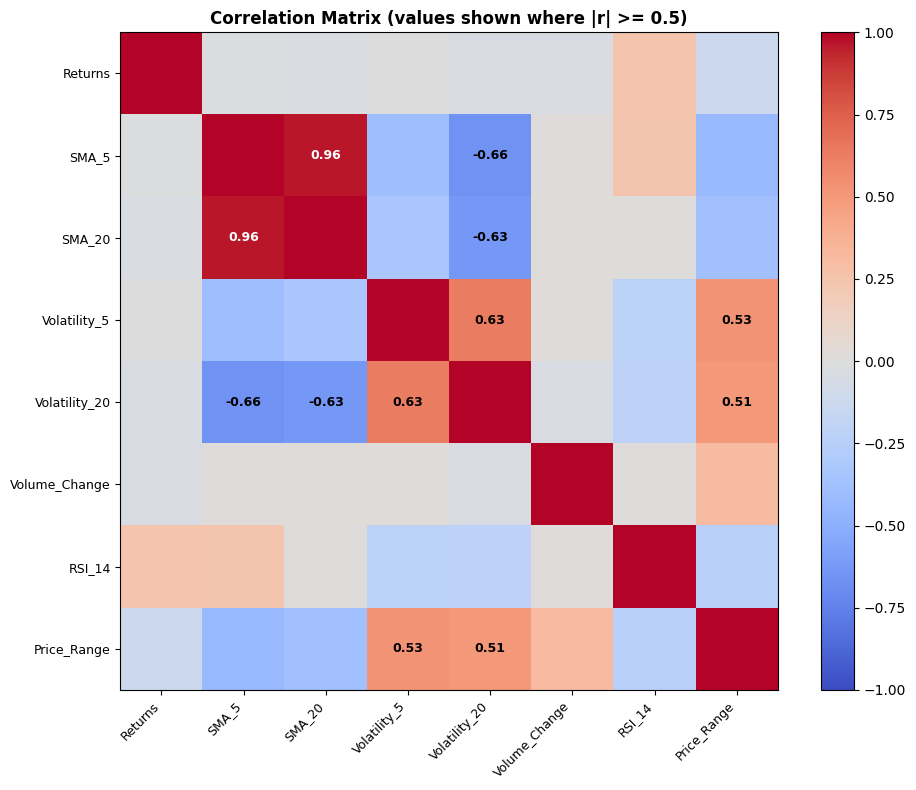

In [17]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.5 and i != j:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if abs(val) > 0.8 else "black",
                    fontsize=9, fontweight="bold")

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
plt.colorbar(cax)
ax.set_title("Correlation Matrix (values shown where |r| >= 0.5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4 — VIF Analysis
VIF > 10 = multicollinearity problem. Drop worst feature and recompute until all <= 10.

In [18]:
def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each feature. Higher = more multicollinear."""
    vif = pd.DataFrame()
    vif["Variable"] = X_df.columns
    vif["VIF"]      = [variance_inflation_factor(X_df.values, i)
                       for i in range(X_df.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

X_vif     = X_train.copy()
iteration = 1

print("=" * 60)
print("VIF ANALYSIS")
print("=" * 60)

while True:
    vif_table = compute_vif(X_vif)
    max_vif   = vif_table.iloc[0]["VIF"]
    worst_var = vif_table.iloc[0]["Variable"]

    print(f"\n--- Iteration {iteration} | {X_vif.shape[1]} features ---")
    print(vif_table.to_string(index=False))

    if max_vif <= 10:
        print(f"\n  All VIF <= 10. Final set: {list(X_vif.columns)}")
        break

    print(f"\n  Dropping '{worst_var}'  (VIF = {max_vif:.2f})")
    X_vif = X_vif.drop(columns=[worst_var])
    iteration += 1

X_after_vif       = X_vif.copy()
selected_vif_cols = X_after_vif.columns.tolist()
print(f"\nFeatures after VIF ({len(selected_vif_cols)}): {selected_vif_cols}")

VIF ANALYSIS

--- Iteration 1 | 8 features ---
     Variable         VIF
        SMA_5 2116.947699
       SMA_20 1845.992721
       RSI_14   32.516761
Volatility_20   12.123180
  Price_Range    8.841419
 Volatility_5    7.139746
Volume_Change    1.201706
      Returns    1.171483

  Dropping 'SMA_5'  (VIF = 2116.95)

--- Iteration 2 | 7 features ---
     Variable       VIF
       SMA_20 11.960726
Volatility_20 11.322024
       RSI_14  9.775748
  Price_Range  8.577759
 Volatility_5  7.116856
Volume_Change  1.200542
      Returns  1.083812

  Dropping 'SMA_20'  (VIF = 11.96)

--- Iteration 3 | 6 features ---
     Variable       VIF
Volatility_20 11.260887
  Price_Range  8.265865
 Volatility_5  7.051967
       RSI_14  3.978780
Volume_Change  1.197027
      Returns  1.054922

  Dropping 'Volatility_20'  (VIF = 11.26)

--- Iteration 4 | 5 features ---
     Variable      VIF
  Price_Range 6.750483
 Volatility_5 5.214188
       RSI_14 3.277200
Volume_Change 1.145991
      Returns 1.052758

  

## Step 5 — RFECV Feature Selection
`TimeSeriesSplit` prevents data leakage from future into training folds.

Optimal features: 3
Selected: ['Returns', 'Volume_Change', 'Price_Range']
Dropped:  ['Volatility_5', 'RSI_14']


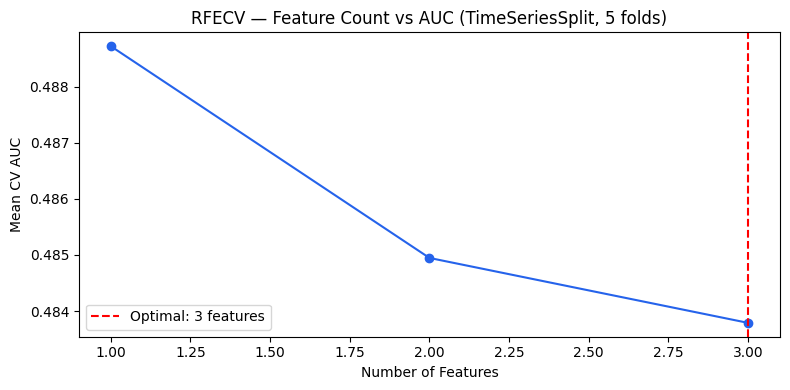

In [19]:
X_train_vif = X_train[selected_vif_cols].dropna()
y_train_vif = y_train.loc[X_train_vif.index]

X_test_vif  = X_test[selected_vif_cols].dropna()
y_test_vif  = y_test.loc[X_test_vif.index]

scaler_rfe     = StandardScaler()
X_train_scaled = scaler_rfe.fit_transform(X_train_vif)
X_test_scaled  = scaler_rfe.transform(X_test_vif)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    step=1,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="roc_auc",
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train_scaled, y_train_vif)

feature_names     = X_train_vif.columns.tolist()
selected_features = [f for f, s in zip(feature_names, rfecv.support_) if s]
dropped_features  = [f for f, s in zip(feature_names, rfecv.support_) if not s]

print(f"Optimal features: {rfecv.n_features_}")
print("Selected:", selected_features)
print("Dropped: ", dropped_features)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"], marker="o", color="#2563EB")
plt.axvline(rfecv.n_features_, color="red", linestyle="--",
            label=f"Optimal: {rfecv.n_features_} features")
plt.xlabel("Number of Features")
plt.ylabel("Mean CV AUC")
plt.title("RFECV — Feature Count vs AUC (TimeSeriesSplit, 5 folds)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Train the Pipeline

In [20]:
X_train_sel = X_train[selected_features].dropna()
y_train_sel = y_train.loc[X_train_sel.index]

X_test_sel  = X_test[selected_features].dropna()
y_test_sel  = y_test.loc[X_test_sel.index]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train_sel, y_train_sel)
print(f"Model trained on {len(selected_features)} features: {selected_features}")

Model trained on 3 features: ['Returns', 'Volume_Change', 'Price_Range']


## Step 7 — Confusion Matrix and Classification Report

              precision    recall  f1-score   support

    Fall (0)       0.40      0.28      0.33       207
    Rise (1)       0.49      0.63      0.55       232

    accuracy                           0.46       439
   macro avg       0.45      0.45      0.44       439
weighted avg       0.45      0.46      0.45       439



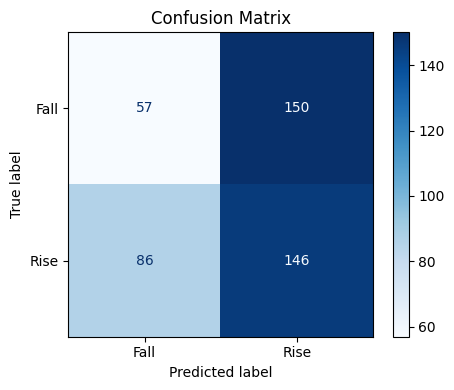

In [21]:
y_pred = pipe.predict(X_test_sel)

print(classification_report(y_test_sel, y_pred, target_names=["Fall (0)", "Rise (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_sel, y_pred, display_labels=["Fall", "Rise"], cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Step 8 — ROC Curve and AUC

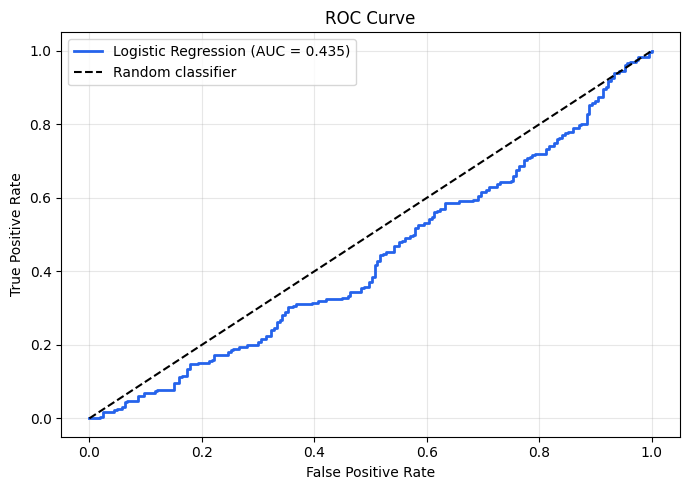

AUC Score: 0.4351


In [22]:
y_proba = pipe.predict_proba(X_test_sel)[:, 1]
fpr, tpr, _ = roc_curve(y_test_sel, y_proba)
auc = roc_auc_score(y_test_sel, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="#2563EB", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

## Step 9 — Threshold Analysis

 Threshold  Accuracy  Precision  Recall    F1  TP  FP  TN  FN
      0.10     0.528      0.528   1.000 0.692 232 207   0   0
      0.15     0.528      0.528   1.000 0.692 232 207   0   0
      0.20     0.528      0.528   1.000 0.692 232 207   0   0
      0.25     0.528      0.528   1.000 0.692 232 207   0   0
      0.30     0.528      0.528   1.000 0.692 232 207   0   0
      0.35     0.528      0.528   1.000 0.692 232 207   0   0
      0.40     0.528      0.528   1.000 0.692 232 207   0   0
      0.45     0.524      0.527   0.983 0.686 228 205   2   4
      0.50     0.462      0.493   0.629 0.553 146 150  57  86
      0.55     0.456      0.419   0.078 0.131  18  25 182 214
      0.60     0.462      0.167   0.004 0.008   1   5 202 231
      0.65     0.472      0.000   0.000 0.000   0   0 207 232
      0.70     0.472      0.000   0.000 0.000   0   0 207 232
      0.75     0.472      0.000   0.000 0.000   0   0 207 232
      0.80     0.472      0.000   0.000 0.000   0   0 207 232
      0.

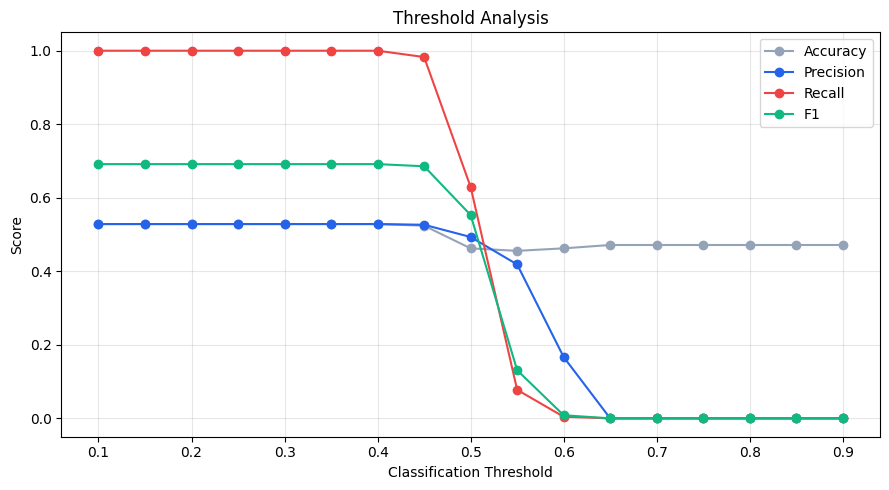


Best threshold by F1: 0.1
Threshold      0.100000
Accuracy       0.528474
Precision      0.528474
Recall         1.000000
F1             0.691505
TP           232.000000
FP           207.000000
TN             0.000000
FN             0.000000
Name: 0, dtype: float64


In [23]:
results = []
for thr in np.arange(0.1, 0.91, 0.05):
    y_pred_t = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_sel, y_pred_t).ravel()
    results.append({
        "Threshold": round(thr, 2),
        "Accuracy":  accuracy_score(y_test_sel, y_pred_t),
        "Precision": precision_score(y_test_sel, y_pred_t, zero_division=0),
        "Recall":    recall_score(y_test_sel, y_pred_t, zero_division=0),
        "F1":        f1_score(y_test_sel, y_pred_t, zero_division=0),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.round(3).to_string(index=False))

plt.figure(figsize=(9, 5))
for metric, color in [("Accuracy","#94a3b8"),("Precision","#2563EB"),("Recall","#ef4444"),("F1","#10b981")]:
    plt.plot(threshold_df["Threshold"], threshold_df[metric], marker="o", label=metric, color=color)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print(f"\nBest threshold by F1: {best_row['Threshold']}")
print(best_row)

## Step 10 — Export the model
Saves .joblib and .txt files. The Streamlit web app loads these at runtime.

In [24]:
model_path    = os.path.join(MODELS_DIR, f"model_{TICKER}.joblib")
features_path = os.path.join(MODELS_DIR, f"features_{TICKER}.txt")

joblib.dump(pipe, model_path)

with open(features_path, "w") as f:
    f.write("\n".join(selected_features))

print(f"Model saved    -> {model_path}")
print(f"Features saved -> {features_path}")

Model saved    -> ../models/model_AMZN.joblib
Features saved -> ../models/features_AMZN.txt


## Step 11 — Train and export all 5 tickers

In [25]:
def train_and_save(ticker: str) -> dict:
    """Full ML pipeline for one ticker."""
    df = pd.read_csv(f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv", parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

    df_model, _ = train_test_split(df, test_size=0.1, shuffle=False, random_state=42)
    X = df_model[FEATURE_COLS]
    y = df_model[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False, random_state=42)

    X_vif = X_train.dropna().copy()
    while True:
        vt = compute_vif(X_vif)
        if vt.iloc[0]["VIF"] <= 10:
            break
        X_vif = X_vif.drop(columns=[vt.iloc[0]["Variable"]])
    vif_cols = X_vif.columns.tolist()

    X_tr = X_train[vif_cols].dropna()
    y_tr = y_train.loc[X_tr.index]
    X_te = X_test[vif_cols].dropna()
    y_te = y_test.loc[X_te.index]

    sc  = StandardScaler()
    rfe = RFECV(LogisticRegression(max_iter=1000, random_state=42),
                step=1, cv=TimeSeriesSplit(n_splits=5),
                scoring="roc_auc", min_features_to_select=3, n_jobs=-1)
    rfe.fit(sc.fit_transform(X_tr), y_tr)
    feats = [f for f, s in zip(vif_cols, rfe.support_) if s]

    pipe_t = Pipeline([("scaler", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000, random_state=42))])
    pipe_t.fit(X_tr[feats], y_tr)
    auc = roc_auc_score(y_te, pipe_t.predict_proba(X_te[feats])[:, 1])

    joblib.dump(pipe_t, f"{MODELS_DIR}/model_{ticker}.joblib")
    with open(f"{MODELS_DIR}/features_{ticker}.txt", "w") as f:
        f.write("\n".join(feats))

    print(f"{ticker:6s}  AUC = {auc:.3f}  features = {feats}")
    return {"ticker": ticker, "auc": round(auc, 4), "features": feats}


TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]
summary = [train_and_save(t) for t in TICKERS]
pd.DataFrame(summary).set_index("ticker")

AMZN    AUC = 0.435  features = ['Returns', 'Volume_Change', 'Price_Range']
AAPL    AUC = 0.477  features = ['Returns', 'Volatility_5', 'RSI_14', 'Price_Range']
MSFT    AUC = 0.513  features = ['Volatility_5', 'RSI_14', 'Price_Range']
GOOG    AUC = 0.480  features = ['Returns', 'SMA_20', 'Volatility_5', 'Volume_Change', 'RSI_14', 'Price_Range']
TSLA    AUC = 0.580  features = ['Returns', 'SMA_20', 'RSI_14']


,auc,features
ticker,,
AMZN,0.4351,"[Returns, Volume_Change, Price_Range]"
AAPL,0.4767,"[Returns, Volatility_5, RSI_14, Price_Range]"
MSFT,0.5130,"[Volatility_5, RSI_14, Price_Range]"
GOOG,0.4796,"[Returns, SMA_20, Volatility_5, Volume_Change,..."
TSLA,0.5802,"[Returns, SMA_20, RSI_14]"
